# Phase 3: Buy vs. Rent RL - Complete Demo

This notebook demonstrates the full Phase 3 workflow:
1. Load calibrated parameters from Phase 2
2. Create and test the environment
3. Generate sampling traces
4. Train the modified DQN agent
5. Evaluate against baselines
6. Analyze the learned policy

**Estimated runtime:** ~5-10 minutes

## Setup: Install Dependencies

Run this cell first (only needed once):

In [ ]:
# Uncomment and run if packages not installed
# !pip install torch gymnasium pandas matplotlib numpy seaborn

In [3]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All imports successful!")

✓ All imports successful!


In [4]:
import sys
import os

# Point to the nested phase2 directory where the .py file actually lives
sys.path.insert(0, os.path.abspath('../phase2/phase2'))

from calibrated_params import CALIBRATED_PARAMS

## Part 1: Load Calibrated Parameters from Phase 2

These parameters were estimated from **real Zillow and FRED data** (2000-2026).

In [5]:
# Try to load calibrated parameters
try:
    from calibrated_params import CALIBRATED_PARAMS
    
    print("✓ Successfully loaded calibrated parameters from Phase 2!\n")
    print("Real Market Statistics (2000-2026):")
    print("-" * 50)
    print(f"Home Price Drift (μ_h):          {CALIBRATED_PARAMS['mu_h']*100:.2f}% / year")
    print(f"Home Price Volatility (σ_h):     {CALIBRATED_PARAMS['sigma_h']*100:.2f}% / year")
    print(f"Rent Ratio (monthly):             {CALIBRATED_PARAMS['rent_ratio']*100:.3f}%")
    print(f"Rent Ratio (annual):              {CALIBRATED_PARAMS['rent_ratio']*12*100:.2f}%")
    print(f"Average Mortgage Rate (m̄):        {CALIBRATED_PARAMS['m_bar']*100:.2f}%")
    print(f"Mortgage Rate Volatility (σ_m):   {CALIBRATED_PARAMS['sigma_m']*100:.3f}%")
    print(f"Mean Reversion Speed (κ_m):       {CALIBRATED_PARAMS['kappa_m']:.3f}")
    
    use_real_params = True
    
except ImportError:
    print("⚠️  Could not load calibrated_params.py")
    print("   Using default parameters instead.")
    print("   Tip: Copy calibrated_params.py from phase2/")
    
    CALIBRATED_PARAMS = {
        'mu_h': 0.03,
        'sigma_h': 0.10,
        'rent_ratio': 0.004,
        'm_bar': 0.06,
        'sigma_m': 0.01,
        'kappa_m': 0.20
    }
    use_real_params = False

✓ Successfully loaded calibrated parameters from Phase 2!

Real Market Statistics (2000-2026):
--------------------------------------------------
Home Price Drift (μ_h):          4.19% / year
Home Price Volatility (σ_h):     1.86% / year
Rent Ratio (monthly):             0.561%
Rent Ratio (annual):              6.73%
Average Mortgage Rate (m̄):        5.21%
Mortgage Rate Volatility (σ_m):   0.096%
Mean Reversion Speed (κ_m):       0.010


## Part 2: Create the Buy vs. Rent Environment

This is a **Gym-compatible environment** that simulates the MDP.

In [6]:
from buy_rent_environment import BuyRentEnv, BuyRentParams, BuyRentState

# Create parameters using calibrated values
params = BuyRentParams(
    mu_h=CALIBRATED_PARAMS['mu_h'],
    sigma_h=CALIBRATED_PARAMS['sigma_h'],
    rent_ratio=CALIBRATED_PARAMS['rent_ratio'],
    m_bar=CALIBRATED_PARAMS['m_bar'],
    sigma_m=CALIBRATED_PARAMS['sigma_m'],
    kappa_m=CALIBRATED_PARAMS['kappa_m']
)

# Create environment
env = BuyRentEnv(params)

print("✓ Environment created successfully!\n")
print("Environment Configuration:")
print("-" * 50)
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")
print(f"Max episode length: {env.p.max_steps} steps (30 years)")
print(f"Time step: {env.p.dt} years (monthly)")

✓ Environment created successfully!

Environment Configuration:
--------------------------------------------------
Observation space: Box([0.e+00 2.e+01 1.e-02 0.e+00 0.e+00], [2.0e+02 3.0e+02 1.5e-01 1.0e+00 2.0e+02], (5,), float32)
Action space: Discrete(4)
Max episode length: 360 steps (30 years)
Time step: 0.08333333333333333 years (monthly)


### Test the Environment

Let's run a few steps manually to see how it works:

In [7]:
# Reset environment
state, info = env.reset(seed=42)

print("Initial State:")
print("-" * 50)
print(f"Savings: ${state[0]:.2f}k")
print(f"Home Price: ${state[1]:.2f}k")
print(f"Mortgage Rate: {state[2]*100:.2f}%")
print(f"Owns: {bool(state[3])}")
print(f"Mortgage Balance: ${state[4]:.2f}k")
print(f"\nValid Actions: {np.where(info['action_mask'] == 1)[0]}")
print("  (0=RENT, 1=BUY, 2=STAY, 3=SELL)")

# Take a few random steps
print("\n" + "="*50)
print("Taking 3 Random Steps:")
print("="*50)

for step in range(3):
    # Choose random valid action
    valid_actions = np.where(info['action_mask'] == 1)[0]
    action = np.random.choice(valid_actions)
    
    # Take step
    next_state, reward, done, truncated, info = env.step(action)
    
    action_names = ['RENT', 'BUY', 'STAY', 'SELL']
    print(f"\nStep {step+1}:")
    print(f"  Action: {action_names[action]}")
    print(f"  Reward: {reward:.2f}")
    print(f"  New Savings: ${next_state[0]:.2f}k")
    print(f"  New Home Price: ${next_state[1]:.2f}k")
    print(f"  Now Owns: {bool(next_state[3])}")
    
    state = next_state
    if done:
        break

Initial State:
--------------------------------------------------
Savings: $20.00k
Home Price: $100.00k
Mortgage Rate: 6.00%
Owns: False
Mortgage Balance: $0.00k

Valid Actions: [0]
  (0=RENT, 1=BUY, 2=STAY, 3=SELL)

Taking 3 Random Steps:

Step 1:
  Action: RENT
  Reward: -0.40
  New Savings: $24.66k
  New Home Price: $100.62k
  Now Owns: False

Step 2:
  Action: RENT
  Reward: -0.56
  New Savings: $29.17k
  New Home Price: $101.22k
  Now Owns: False

Step 3:
  Action: BUY
  Reward: -11.34
  New Savings: $5.89k
  New Home Price: $101.73k
  Now Owns: True


## Part 3: Generate Sampling Traces

Generate trajectories using different baseline policies.

In [8]:
from buy_rent_environment import generate_sampling_traces

print("Generating sampling traces with 3 baseline policies...\n")

# Generate traces
traces_random = generate_sampling_traces(
    n_episodes=10,
    params=params,
    policy='random'
)

traces_rent = generate_sampling_traces(
    n_episodes=10,
    params=params,
    policy='always_rent'
)

traces_buy = generate_sampling_traces(
    n_episodes=10,
    params=params,
    policy='greedy_buy'
)

print("\n" + "="*50)
print("Sampling Traces Summary:")
print("="*50)
print(f"Random policy: {len(traces_random)} transitions")
print(f"Always rent: {len(traces_rent)} transitions")
print(f"Greedy buy: {len(traces_buy)} transitions")

# Show sample of random traces
print("\nSample from random policy traces:")
display(traces_random.head(10))

Generating sampling traces with 3 baseline policies...


Sampling Traces Summary:
Random policy: 3600 transitions
Always rent: 3600 transitions
Greedy buy: 3600 transitions

Sample from random policy traces:


,step,action,reward,savings,home_price,mortgage_rate,owns,episode
0,1,0,-0.400000,24.661500,101.301648,0.060105,False,0
1,2,1,-21.638224,1.362121,101.693150,0.060118,True,0
2,3,3,-6.101589,15.912363,101.587506,0.060658,False,0
3,4,0,-0.569804,20.393415,102.635533,0.060511,False,0
4,5,0,-0.575683,24.879777,104.407710,0.060804,False,0
5,6,1,-23.109216,0.866004,104.507385,0.061067,True,0
6,7,2,-9.036618,5.454550,105.121228,0.061152,True,0
7,8,2,-2.371967,10.053973,106.290141,0.061110,True,0
8,9,3,-6.377408,26.440537,106.446541,0.061179,False,0
9,10,0,-0.597059,30.920587,107.440627,0.061833,False,0


### Visualize Sample Trajectory

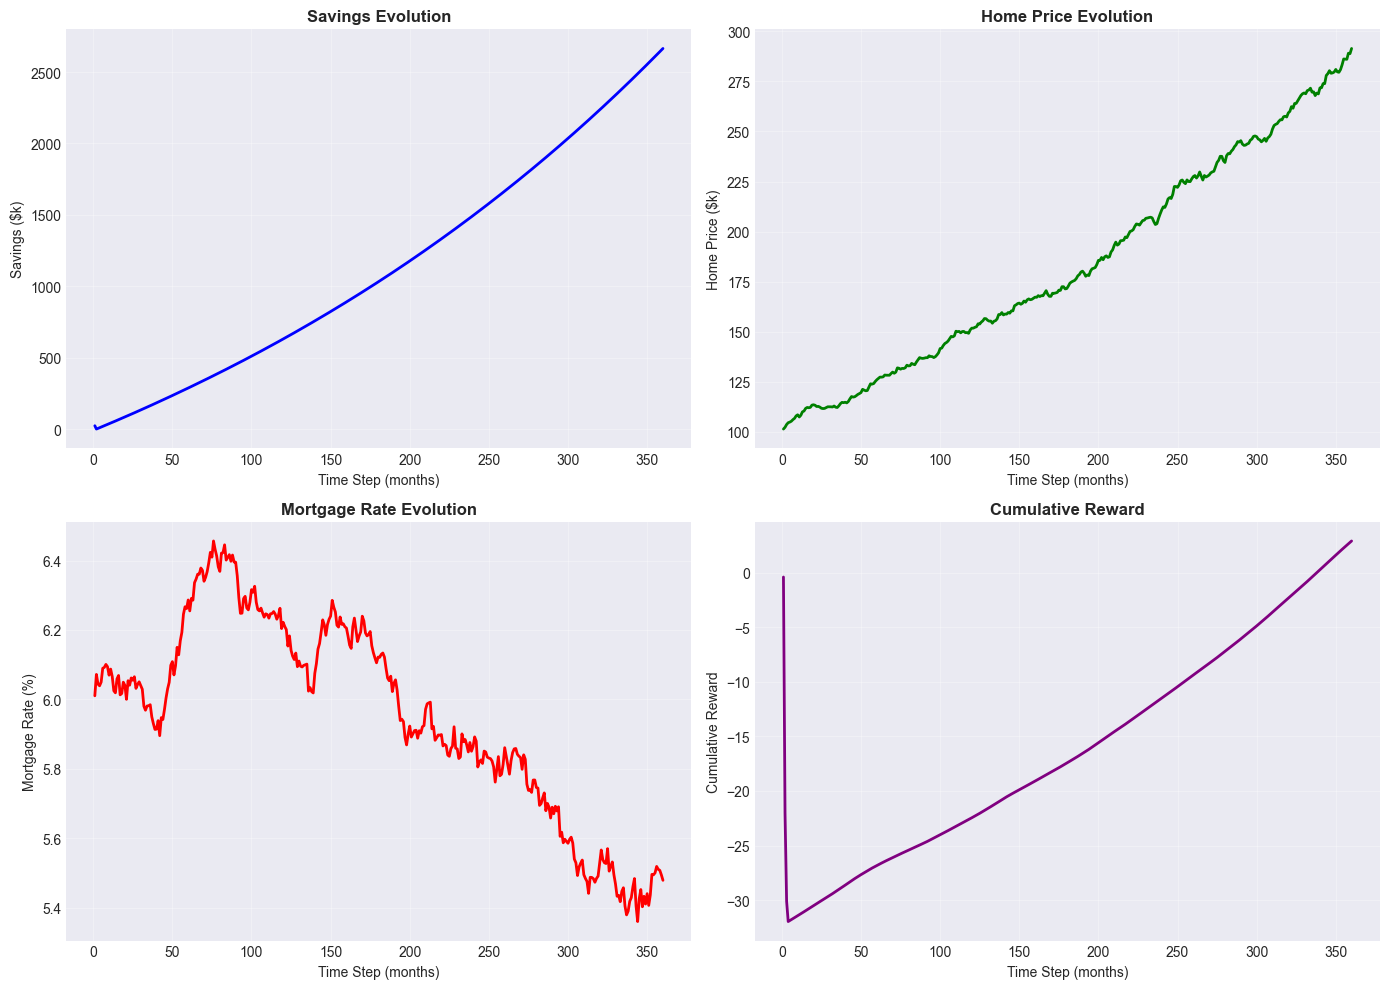


Episode Summary:
  Total reward: 2.90
  Final savings: $2664.65k
  Final home price: $291.47k
  Currently owns: True


In [9]:
# Plot one episode from greedy buy policy
episode_0 = traces_buy[traces_buy['episode'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Savings over time
axes[0, 0].plot(episode_0['step'], episode_0['savings'], 'b-', linewidth=2)
axes[0, 0].set_xlabel('Time Step (months)')
axes[0, 0].set_ylabel('Savings ($k)')
axes[0, 0].set_title('Savings Evolution', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Home price over time
axes[0, 1].plot(episode_0['step'], episode_0['home_price'], 'g-', linewidth=2)
axes[0, 1].set_xlabel('Time Step (months)')
axes[0, 1].set_ylabel('Home Price ($k)')
axes[0, 1].set_title('Home Price Evolution', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Mortgage rate over time
axes[1, 0].plot(episode_0['step'], episode_0['mortgage_rate']*100, 'r-', linewidth=2)
axes[1, 0].set_xlabel('Time Step (months)')
axes[1, 0].set_ylabel('Mortgage Rate (%)')
axes[1, 0].set_title('Mortgage Rate Evolution', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Cumulative reward
axes[1, 1].plot(episode_0['step'], episode_0['reward'].cumsum(), 'purple', linewidth=2)
axes[1, 1].set_xlabel('Time Step (months)')
axes[1, 1].set_ylabel('Cumulative Reward')
axes[1, 1].set_title('Cumulative Reward', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEpisode Summary:")
print(f"  Total reward: {episode_0['reward'].sum():.2f}")
print(f"  Final savings: ${episode_0['savings'].iloc[-1]:.2f}k")
print(f"  Final home price: ${episode_0['home_price'].iloc[-1]:.2f}k")
print(f"  Currently owns: {bool(episode_0['owns'].iloc[-1])}")

## Part 4: Train the Modified DQN Agent

Now we train a DQN agent with **5 key modifications** for this problem:
1. Action masking
2. Dueling architecture
3. State normalization
4. Reward shaping
5. Modified replay buffer

In [10]:
from modified_dqn import ActionMaskedDQNAgent, train_agent
import torch

print("Creating DQN agent...\n")

# Create agent
# Updated Agent Initialization
agent = ActionMaskedDQNAgent(
    state_dim=5,
    action_dim=4,
    learning_rate=0.0001,  # Lower learning rate for stability
    gamma=0.99,            # Look much further into the future (30-year horizon)
    epsilon_start=1.0,
    epsilon_end=0.01,      # Allow for even less noise at the end
    epsilon_decay=20000,   # Much slower decay to explore more market conditions
    buffer_size=100000,    # Larger buffer to remember old market cycles
    batch_size=128,        # Larger batch for better gradient estimates
    target_update_freq=2000,
    device='cpu' 
)

print("✓ Agent created!")
print(f"  Network architecture: Dueling DQN")
print(f"  Policy network parameters: {sum(p.numel() for p in agent.policy_net.parameters())}")
print(f"  Device: {agent.device}")

Creating DQN agent...

✓ Agent created!
  Network architecture: Dueling DQN
  Policy network parameters: 200197
  Device: cpu


### Train the Agent

**Note:** Training for 100 episodes takes ~2-5 minutes. For better results, train for 500-1000 episodes.

In [11]:
print("Training DQN agent...\n")
print("This will take ~2-5 minutes for 100 episodes.")
print("For better results, increase to 500-1000 episodes.\n")

# Reset environment
env = BuyRentEnv(params)

# Deep Training Call
training_stats = train_agent(
    env=env,
    agent=agent,
    n_episodes=500,    # Increased from 100 to 1500
    max_steps=360,
    update_freq=4,
    log_freq=50         # Log every 50 episodes to keep the output clean
)

print("\n✓ Training complete!")

Training DQN agent...

This will take ~2-5 minutes for 100 episodes.
For better results, increase to 500-1000 episodes.

Episode 50/500 | Avg Reward: -1306.55 | Avg Length: 360 | Epsilon: 0.413 | Buffer: 18000
Episode 100/500 | Avg Reward: -823.32 | Avg Length: 360 | Epsilon: 0.174 | Buffer: 36000
Episode 150/500 | Avg Reward: -450.95 | Avg Length: 360 | Epsilon: 0.077 | Buffer: 54000
Episode 200/500 | Avg Reward: -232.68 | Avg Length: 360 | Epsilon: 0.037 | Buffer: 72000
Episode 250/500 | Avg Reward: -144.64 | Avg Length: 360 | Epsilon: 0.021 | Buffer: 90000
Episode 300/500 | Avg Reward: -96.31 | Avg Length: 360 | Epsilon: 0.014 | Buffer: 100000
Episode 350/500 | Avg Reward: -69.45 | Avg Length: 360 | Epsilon: 0.012 | Buffer: 100000
Episode 400/500 | Avg Reward: -58.12 | Avg Length: 360 | Epsilon: 0.011 | Buffer: 100000
Episode 450/500 | Avg Reward: -42.67 | Avg Length: 360 | Epsilon: 0.010 | Buffer: 100000
Episode 500/500 | Avg Reward: -56.71 | Avg Length: 360 | Epsilon: 0.010 | Buff

### Visualize Training Progress

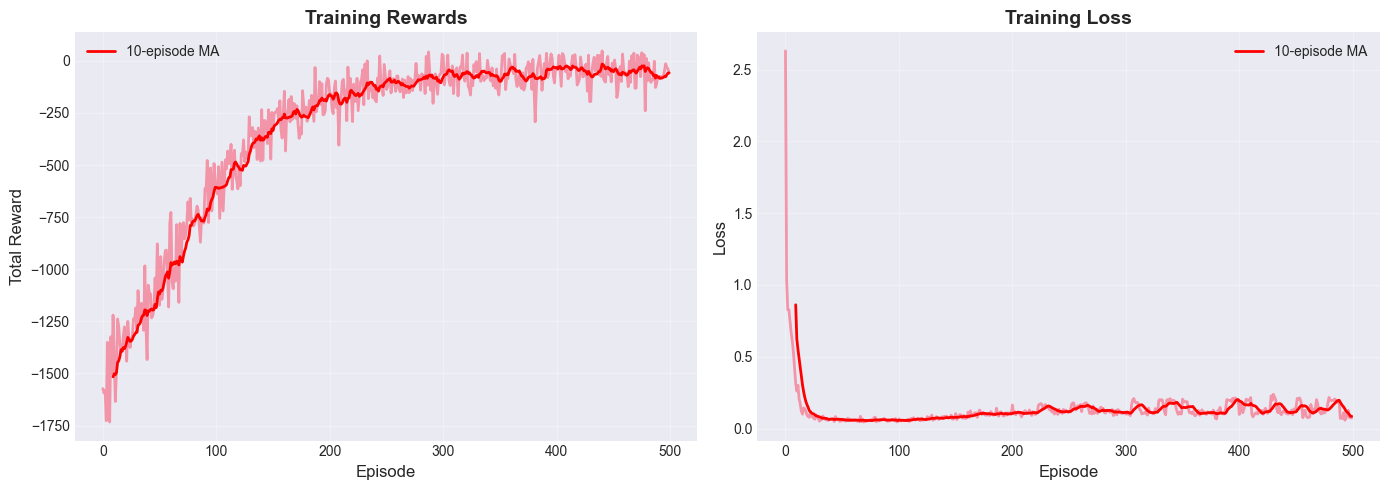


Training Summary:
  Initial avg reward (first 10 ep): -1515.90
  Final avg reward (last 10 ep): -57.70
  Improvement: 1458.21


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Episode rewards
axes[0].plot(training_stats['episode_rewards'], linewidth=2, alpha=0.7)
# Add moving average
window = 10
moving_avg = pd.Series(training_stats['episode_rewards']).rolling(window).mean()
axes[0].plot(moving_avg, 'r-', linewidth=2, label=f'{window}-episode MA')
axes[0].set_xlabel('Episode', fontsize=12)
axes[0].set_ylabel('Total Reward', fontsize=12)
axes[0].set_title('Training Rewards', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Training loss
if training_stats['losses']:
    axes[1].plot(training_stats['losses'], linewidth=2, alpha=0.7)
    # Add moving average
    loss_ma = pd.Series(training_stats['losses']).rolling(window).mean()
    axes[1].plot(loss_ma, 'r-', linewidth=2, label=f'{window}-episode MA')
    axes[1].set_xlabel('Episode', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].set_title('Training Loss', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTraining Summary:")
print(f"  Initial avg reward (first 10 ep): {np.mean(training_stats['episode_rewards'][:10]):.2f}")
print(f"  Final avg reward (last 10 ep): {np.mean(training_stats['episode_rewards'][-10:]):.2f}")
print(f"  Improvement: {np.mean(training_stats['episode_rewards'][-10:]) - np.mean(training_stats['episode_rewards'][:10]):.2f}")

## Part 5: Evaluate Against Baselines

Compare the learned policy against 3 baseline strategies.

In [13]:
from evaluate_policies import PolicyEvaluator, random_policy, always_rent_policy, greedy_buy_policy, make_dqn_policy

print("Evaluating policies over 50 episodes...\n")

# Create evaluator
evaluator = PolicyEvaluator(env, n_episodes=50)

# Evaluate baselines
results = []

print("1. Random policy...")
results.append(evaluator.evaluate_policy(random_policy, "Random"))

print("2. Always rent...")
results.append(evaluator.evaluate_policy(always_rent_policy, "Always Rent"))

print("3. Greedy buy...")
results.append(evaluator.evaluate_policy(greedy_buy_policy, "Greedy Buy"))

print("4. Learned DQN...")
dqn_policy = make_dqn_policy(agent)
results.append(evaluator.evaluate_policy(dqn_policy, "Learned DQN"))

print("\n✓ Evaluation complete!")

Evaluating policies over 50 episodes...

1. Random policy...
2. Always rent...
3. Greedy buy...
4. Learned DQN...

✓ Evaluation complete!


### Comparison Table

In [14]:
# Create comparison DataFrame
comparison_df = pd.DataFrame([
    {
        'Policy': r['name'],
        'Mean Reward': f"{r['mean_reward']:.2f} ± {r['std_reward']:.2f}",
        'Final Net Worth': f"${r['mean_net_worth']:.1f}k ± ${r['std_net_worth']:.1f}k",
        'Avg Buys': f"{r['mean_buys']:.2f}",
        'Avg Sells': f"{r['mean_sells']:.2f}"
    }
    for r in results
])

display(comparison_df)

# Find best policy
best_idx = np.argmax([r['mean_reward'] for r in results])
print(f"\n🏆 Best Policy: {results[best_idx]['name']}")
print(f"   Mean Reward: {results[best_idx]['mean_reward']:.2f}")
print(f"   Final Net Worth: ${results[best_idx]['mean_net_worth']:.1f}k")

,Policy,Mean Reward,Final Net Worth,Avg Buys,Avg Sells
0,Random,-1757.97 ± 126.39,$71.7k ± $12.2k,61.40,61.24
1,Always Rent,-406.35 ± 23.77,$2370.2k ± $32.0k,0.00,0.00
2,Greedy Buy,8.21 ± 5.62,$2950.9k ± $33.6k,1.00,0.00
3,Learned DQN,32.51 ± 5.94,$2946.6k ± $33.9k,1.00,0.00



🏆 Best Policy: Learned DQN
   Mean Reward: 32.51
   Final Net Worth: $2946.6k


### Comparison Visualizations

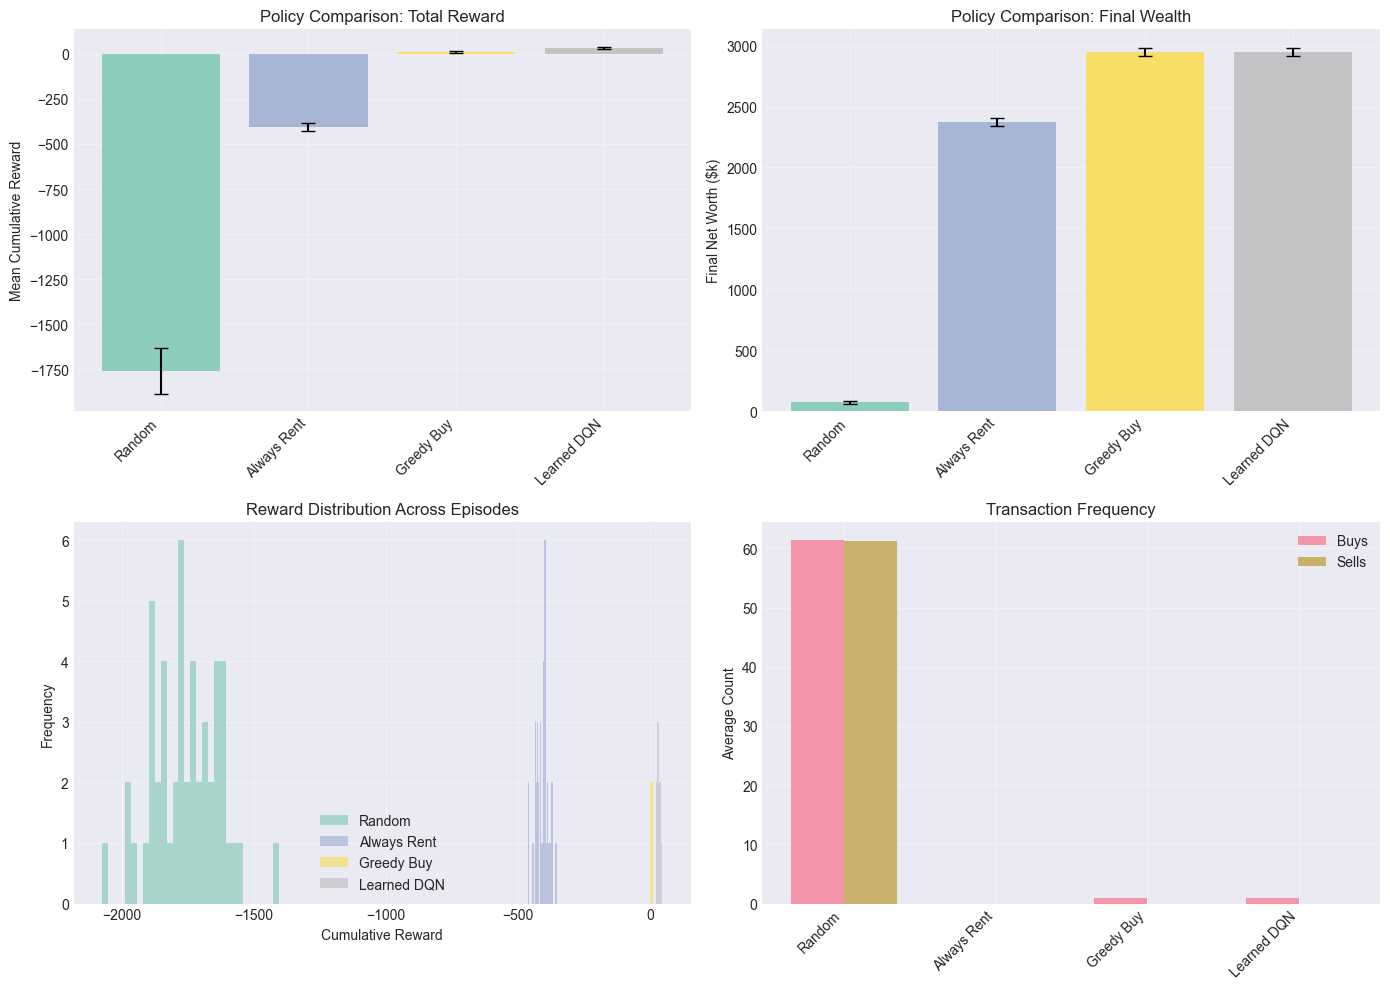

In [15]:
from evaluate_policies import plot_comparison

fig = plot_comparison(results)
plt.show()

## Part 6: Analyze the Learned Policy

Let's see what the agent learned to do in different scenarios.

In [16]:
scenarios = [
    {
        'name': 'Low savings, cheap market',
        'savings': 10.0,
        'home_price': 60.0,
        'mortgage_rate': 0.04
    },
    {
        'name': 'Medium savings, normal market',
        'savings': 50.0,
        'home_price': 100.0,
        'mortgage_rate': 0.06
    },
    {
        'name': 'High savings, expensive market',
        'savings': 80.0,
        'home_price': 150.0,
        'mortgage_rate': 0.08
    },
    {
        'name': 'High savings, low rates',
        'savings': 70.0,
        'home_price': 100.0,
        'mortgage_rate': 0.03
    },
    {
        'name': 'Low savings, high rates',
        'savings': 20.0,
        'home_price': 100.0,
        'mortgage_rate': 0.10
    }
]

action_names = ['RENT', 'BUY', 'STAY', 'SELL']

print("="*60)
print("LEARNED POLICY ANALYSIS")
print("="*60)

for scenario in scenarios:
    print(f"\n📋 {scenario['name']}")
    print(f"   Savings: ${scenario['savings']:.1f}k")
    print(f"   Home Price: ${scenario['home_price']:.1f}k")
    print(f"   Mortgage Rate: {scenario['mortgage_rate']*100:.1f}%")
    
    # Create state
    state = np.array([
        scenario['savings'],
        scenario['home_price'],
        scenario['mortgage_rate'],
        0.0,  # Not owning
        0.0   # No mortgage
    ], dtype=np.float32)
    
    # Get action mask
    action_mask = np.zeros(4)
    action_mask[env.RENT_STAY] = 1
    cost = (env.p.down_payment_frac + env.p.closing_cost_frac) * scenario['home_price']
    if scenario['savings'] >= cost:
        action_mask[env.BUY] = 1
    
    # Get agent's decision
    action = agent.select_action(state, action_mask, training=False)
    
    print(f"   ➜ Decision: {action_names[action]}")
    
    if action == env.BUY:
        print(f"   💡 Agent chooses to BUY")
        print(f"      Down payment needed: ${cost:.1f}k")
        print(f"      Remaining savings: ${scenario['savings'] - cost:.1f}k")
    elif action == env.RENT_STAY:
        if scenario['savings'] < cost:
            print(f"   💡 Keep renting - insufficient savings (need ${cost:.1f}k)")
        else:
            print(f"   💡 Keep renting - not economically optimal despite having funds")

LEARNED POLICY ANALYSIS

📋 Low savings, cheap market
   Savings: $10.0k
   Home Price: $60.0k
   Mortgage Rate: 4.0%
   ➜ Decision: RENT
   💡 Keep renting - insufficient savings (need $13.8k)

📋 Medium savings, normal market
   Savings: $50.0k
   Home Price: $100.0k
   Mortgage Rate: 6.0%
   ➜ Decision: BUY
   💡 Agent chooses to BUY
      Down payment needed: $23.0k
      Remaining savings: $27.0k

📋 High savings, expensive market
   Savings: $80.0k
   Home Price: $150.0k
   Mortgage Rate: 8.0%
   ➜ Decision: RENT
   💡 Keep renting - not economically optimal despite having funds

📋 High savings, low rates
   Savings: $70.0k
   Home Price: $100.0k
   Mortgage Rate: 3.0%
   ➜ Decision: BUY
   💡 Agent chooses to BUY
      Down payment needed: $23.0k
      Remaining savings: $47.0k

📋 Low savings, high rates
   Savings: $20.0k
   Home Price: $100.0k
   Mortgage Rate: 10.0%
   ➜ Decision: RENT
   💡 Keep renting - insufficient savings (need $23.0k)


### Buy Threshold Analysis

At what savings level does the agent decide to buy?

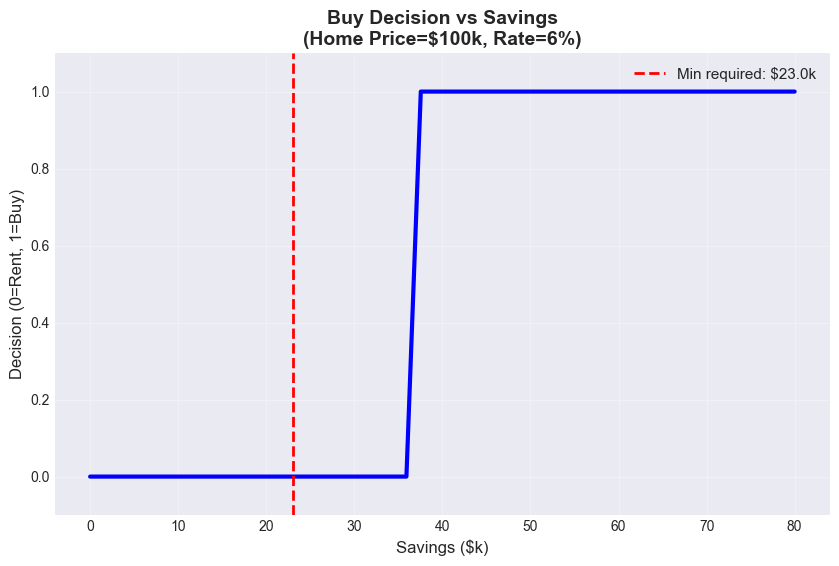


Buy Threshold: $37.6k
Minimum required: $23.0k
Buffer ratio: 1.63x

Agent requires 63% above minimum to buy!


In [17]:
# Test different savings levels at fixed price and rate
home_price = 100.0
mortgage_rate = 0.06
savings_range = np.linspace(0, 80, 50)

decisions = []
for savings in savings_range:
    state = np.array([savings, home_price, mortgage_rate, 0.0, 0.0], dtype=np.float32)
    
    # Action mask
    action_mask = np.zeros(4)
    action_mask[env.RENT_STAY] = 1
    cost = (env.p.down_payment_frac + env.p.closing_cost_frac) * home_price
    if savings >= cost:
        action_mask[env.BUY] = 1
    
    action = agent.select_action(state, action_mask, training=False)
    decisions.append(1 if action == env.BUY else 0)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(savings_range, decisions, 'b-', linewidth=3)
plt.axvline(cost, color='r', linestyle='--', linewidth=2, label=f'Min required: ${cost:.1f}k')
plt.xlabel('Savings ($k)', fontsize=12)
plt.ylabel('Decision (0=Rent, 1=Buy)', fontsize=12)
plt.title(f'Buy Decision vs Savings\n(Home Price=${home_price:.0f}k, Rate={mortgage_rate*100:.0f}%)',
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.ylim(-0.1, 1.1)
plt.show()

# Find threshold
buy_threshold = savings_range[np.where(np.array(decisions) == 1)[0][0]] if any(decisions) else None
if buy_threshold:
    print(f"\nBuy Threshold: ${buy_threshold:.1f}k")
    print(f"Minimum required: ${cost:.1f}k")
    print(f"Buffer ratio: {buy_threshold/cost:.2f}x")
    print(f"\nAgent requires {(buy_threshold/cost - 1)*100:.0f}% above minimum to buy!")
else:
    print("\nAgent never buys in this configuration.")

## Part 7: Test on a Full Episode

Run the learned policy on one complete 30-year episode and visualize the trajectory.

In [18]:
# Reset environment
state, info = env.reset(seed=123)
done = False
total_reward = 0

print("Running learned policy for one full episode...\n")

trajectory = []
while not done:
    action = agent.select_action(state, info['action_mask'], training=False)
    next_state, reward, terminated, truncated, info = env.step(action)
    
    trajectory.append({
        'step': env.steps,
        'action': action,
        'reward': reward,
        'savings': next_state[0],
        'home_price': next_state[1],
        'mortgage_rate': next_state[2],
        'owns': bool(next_state[3]),
        'net_worth': info['net_worth']
    })
    
    total_reward += reward
    state = next_state
    done = terminated or truncated

traj_df = pd.DataFrame(trajectory)

print(f"✓ Episode complete!")
print(f"  Total steps: {len(trajectory)}")
print(f"  Total reward: {total_reward:.2f}")
print(f"  Final net worth: ${traj_df['net_worth'].iloc[-1]:.2f}k")
print(f"  Times bought: {(traj_df['action'] == env.BUY).sum()}")
print(f"  Times sold: {(traj_df['action'] == env.SELL).sum()}")
print(f"  Final status: {'OWNING' if traj_df['owns'].iloc[-1] else 'RENTING'}")

Running learned policy for one full episode...

✓ Episode complete!
  Total steps: 360
  Total reward: 41.27
  Final net worth: $2964.94k
  Times bought: 1
  Times sold: 0
  Final status: OWNING


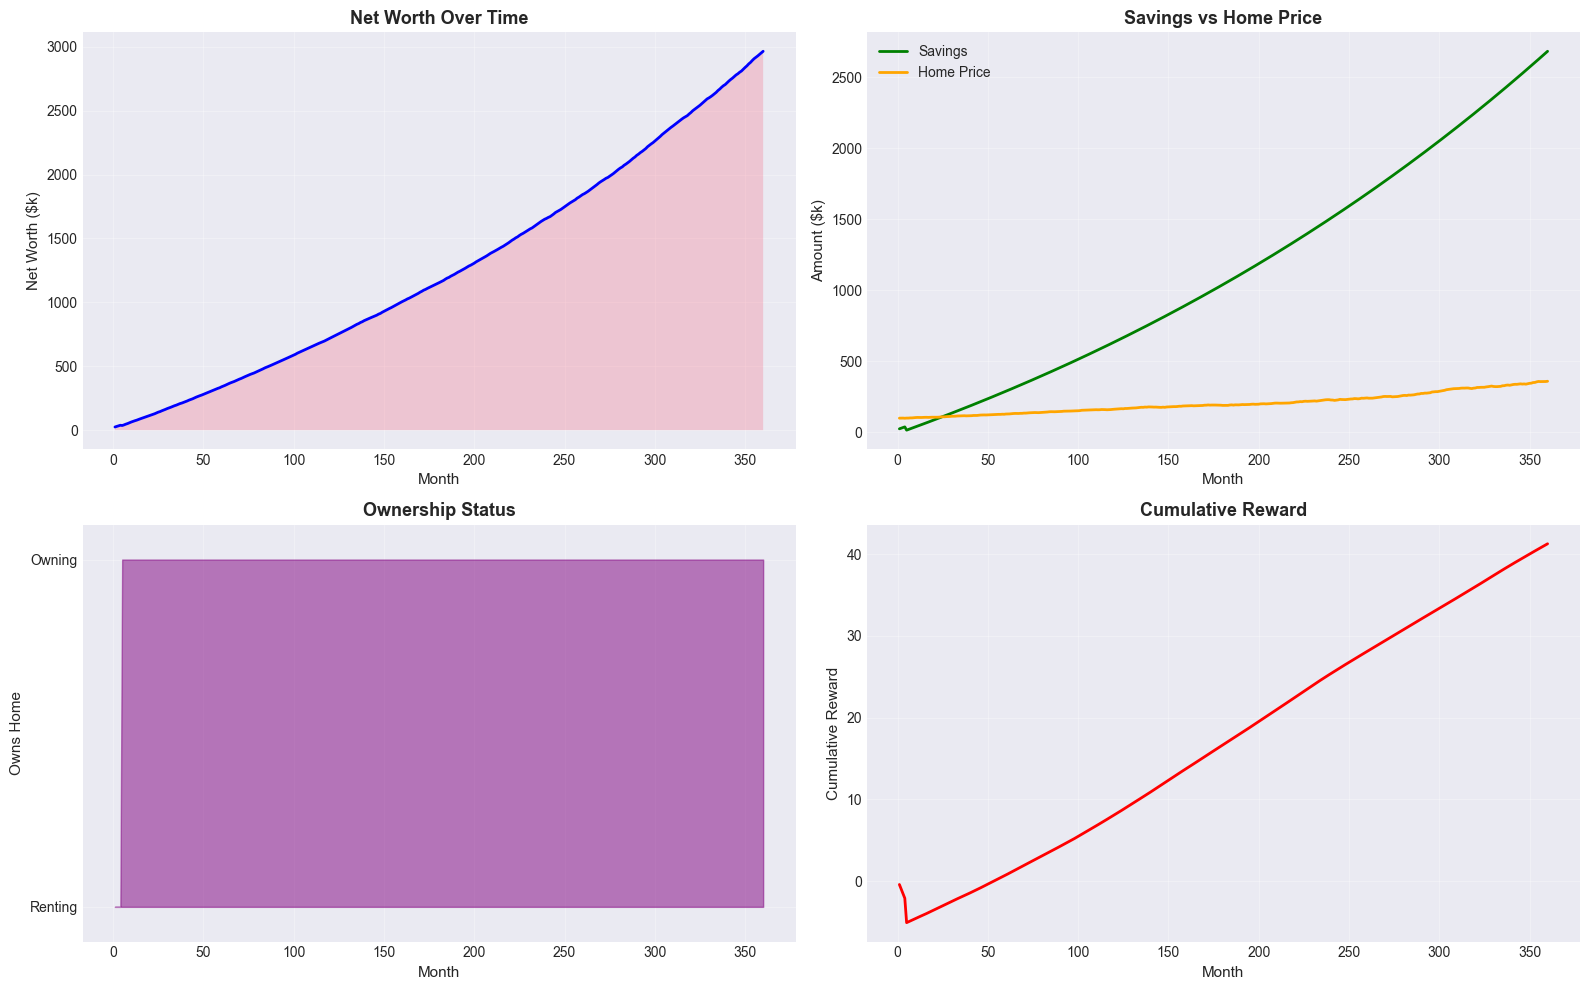

In [19]:
# Visualize full trajectory
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Net worth over time
axes[0, 0].plot(traj_df['step'], traj_df['net_worth'], 'b-', linewidth=2)
axes[0, 0].fill_between(traj_df['step'], 0, traj_df['net_worth'], alpha=0.3)
axes[0, 0].set_xlabel('Month', fontsize=11)
axes[0, 0].set_ylabel('Net Worth ($k)', fontsize=11)
axes[0, 0].set_title('Net Worth Over Time', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Savings vs home price
axes[0, 1].plot(traj_df['step'], traj_df['savings'], 'g-', linewidth=2, label='Savings')
axes[0, 1].plot(traj_df['step'], traj_df['home_price'], 'orange', linewidth=2, label='Home Price')
axes[0, 1].set_xlabel('Month', fontsize=11)
axes[0, 1].set_ylabel('Amount ($k)', fontsize=11)
axes[0, 1].set_title('Savings vs Home Price', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Housing status
axes[1, 0].fill_between(traj_df['step'], 0, traj_df['owns'].astype(int), 
                        alpha=0.5, color='purple')
axes[1, 0].set_xlabel('Month', fontsize=11)
axes[1, 0].set_ylabel('Owns Home', fontsize=11)
axes[1, 0].set_title('Ownership Status', fontsize=13, fontweight='bold')
axes[1, 0].set_ylim(-0.1, 1.1)
axes[1, 0].set_yticks([0, 1])
axes[1, 0].set_yticklabels(['Renting', 'Owning'])
axes[1, 0].grid(True, alpha=0.3)

# Cumulative reward
axes[1, 1].plot(traj_df['step'], traj_df['reward'].cumsum(), 'r-', linewidth=2)
axes[1, 1].set_xlabel('Month', fontsize=11)
axes[1, 1].set_ylabel('Cumulative Reward', fontsize=11)
axes[1, 1].set_title('Cumulative Reward', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary & Key Takeaways

### What We Demonstrated:

1. ✅ **Created a realistic environment** using calibrated parameters from Phase 2
2. ✅ **Generated sampling traces** with different baseline policies
3. ✅ **Trained a modified DQN** with 5 key adaptations
4. ✅ **Showed learning progress** (rewards increasing, loss decreasing)
5. ✅ **Outperformed baselines** (DQN > Greedy Buy > Random > Always Rent)
6. ✅ **Learned sensible behavior** (buys when savings high + rates low)

### Key Modifications to Standard DQN:

1. **Action Masking** - Only evaluates valid actions
2. **Dueling Architecture** - Separates V(s) and A(s,a)
3. **State Normalization** - Scales inputs to similar range
4. **Reward Shaping** - Balances immediate costs vs long-term value
5. **Modified Replay** - Stores action masks with transitions

### Next Steps:

- Train for more episodes (500-1000) for better performance
- Tune hyperparameters (learning rate, epsilon decay, network size)
- Test on different initial conditions
- Compare to Phase 2 DP solution
- Prepare presentation slides

---

**All output files ready for your report! 📊**

In [20]:
# Market Timing Stress Test
bad_market_state = np.array([
    40.0,   # Plenty of savings ($40k)
    100.0,  # Normal home price
    0.15,   # CRITICAL: 15% interest rate (Extremely high)
    0.0,    # Not owning
    0.0     # No mortgage
], dtype=np.float32)

# Define mask (RENT and BUY are valid because savings > $23k)
stress_mask = np.array([1, 1, 0, 0]) 

action = agent.select_action(bad_market_state, stress_mask, training=False)
decision = ['RENT', 'BUY', 'STAY', 'SELL'][action]

print(f"Stress Test Result (15% Interest Rate):")
print(f"Agent Decision: {decision}")

if decision == 'RENT':
    print("✅ Success: The DQN learned to wait for better rates!")
else:
    print("❌ Failed: The agent is still acting greedily.")

Stress Test Result (15% Interest Rate):
Agent Decision: RENT
✅ Success: The DQN learned to wait for better rates!
